# 02: Spillover Exposure Mapping

This notebook turns the MovieLens seed slates from the setup notebook into a causal simulation dataset for studying interference and spillovers.

The key idea is simple. Recommendation items in the same slate compete for limited attention. If one lower-ranked movie is promoted to the top of a slate, the promoted movie may gain visibility, but other movies can lose visibility or attention. The strongest spillover should usually fall on nearby substitute items, such as movies in the same genre cluster.

This notebook does **not** estimate causal effects yet. Instead, it defines the experimental structure that later estimators will use:

- the item-row unit of analysis,
- the slate-level randomized promotion assignment,
- direct treatment exposure for promoted focal movies,
- spillover exposure for non-promoted movies in the same slate,
- stronger same-cluster spillover exposure for substitute movies,
- simulated post-promotion outcomes based on relevance, visibility, and competition.

The result is an analysis-ready table with known assignment probabilities. That matters because the later notebooks can estimate direct, indirect, and total effects while clearly explaining what is randomized and what is simulated.


<!-- dataset-experiment-context -->
## Dataset and Simulation Design Context

This project uses MovieLens 32M as a realistic user-item preference source. MovieLens contains ratings and movie metadata, but it does not contain production recommendation impressions, randomized promotions, or observed slate outcomes.

Because the public data do not include a real experiment, the project builds a transparent simulation. It constructs recommendation slates, selects lower-ranked focal movies, randomizes focal promotion at the slate level, and generates outcomes through an explicit competition model.

The simulated experiment is designed to teach interference. Promoting one item can increase that item's engagement while reducing attention for substitutes and neighboring items. The estimands are direct focal effects, spillover effects, and total slate value, so the project emphasizes experiment design and measurement logic as a teaching workflow.

**Role of this notebook.** This notebook constructs the simulated promotion design, exposure mappings, and outcome mechanism used to study direct and spillover effects.

<!-- mathematical-setup -->

## Mathematical Setup

An exposure mapping reduces a complex assignment vector \(\mathbf{D}\) to a lower-dimensional exposure label:

$$
E_i = f_i(\mathbf{D}, G),
$$

where \(G\) is the item or slate relationship structure. In this project, \(E_i\) can include direct promotion, same-slate competition, or cluster-level spillover exposure. Once the exposure label is defined, the potential outcome is indexed by that label:

$$
Y_i(\mathbf{D}) = Y_i(E_i)
\quad \text{under the chosen exposure mapping.}
$$

The mapping matters because all later estimators compare outcomes across exposure states. A poor mapping can hide interference, while an overly detailed mapping can create sparse cells that are hard to estimate.


#### 1. Environment and Paths

This cell imports the libraries used in the notebook and finds the repository root by searching upward for the processed MovieLens files. This makes the notebook work whether it is run from the repository root, from JupyterLab, or through `nbconvert`.


In [1]:
# Set up environment and paths.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "processed" / "movielens_interference_slate_seed.parquet").exists()
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "interference_spillover_effects"
WRITEUP_DIR = NOTEBOOK_DIR / "writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SLATE_SEED_PATH = PROCESSED_DIR / "movielens_interference_slate_seed.parquet"
ITEMS_PATH = PROCESSED_DIR / "movielens_interference_items.parquet"
USERS_PATH = PROCESSED_DIR / "movielens_interference_user_features.parquet"

SLATE_SEED_PATH.exists(), ITEMS_PATH.exists(), USERS_PATH.exists()


(True, True, True)

All three checks should return `True`. These are the processed outputs from the setup notebook: seed slates, item features, and user features. This notebook uses those files as fixed inputs so the exposure mapping is reproducible.


#### 2. Load the Seed Slates and Feature Tables

The seed slate table contains one row per user-slate-movie candidate. It already has a seed position, observed relevance from the user's rating, and a genre-based spillover cluster. This cell loads the seed table and attaches user and item features that will be useful for balance checks and outcome simulation.


In [2]:
# Load the seed slates and feature tables.
slate_seed = pd.read_parquet(SLATE_SEED_PATH)
items = pd.read_parquet(ITEMS_PATH)
users = pd.read_parquet(USERS_PATH)

item_feature_cols = [
    "movieId",
    "sample_rating_count",
    "sample_mean_rating",
    "sample_liked_rate",
    "popularity_bucket",
]
user_feature_cols = [
    "userId",
    "n_ratings",
    "mean_rating",
    "liked_rate",
    "active_years",
    "unique_primary_genres",
    "activity_span_days",
]

slate_base = (
    slate_seed.merge(items[item_feature_cols], on="movieId", how="left")
    .merge(users[user_feature_cols], on="userId", how="left", suffixes=("", "_user"))
)

load_summary = pd.DataFrame(
    {
        "metric": [
            "slate_item_rows",
            "unique_slates",
            "unique_users",
            "unique_movies",
            "slate_size_min",
            "slate_size_max",
            "spillover_clusters",
        ],
        "value": [
            len(slate_base),
            slate_base["slate_id"].nunique(),
            slate_base["userId"].nunique(),
            slate_base["movieId"].nunique(),
            slate_base.groupby("slate_id").size().min(),
            slate_base.groupby("slate_id").size().max(),
            slate_base["spillover_cluster"].nunique(),
        ],
    }
)

display(load_summary)
display(slate_base.head())


,metric,value
0,slate_item_rows,36000
1,unique_slates,3000
2,unique_users,3000
3,unique_movies,5668
4,slate_size_min,12
5,slate_size_max,12
6,spillover_clusters,19


,slate_id,userId,movieId,title,genres,primary_genre,spillover_cluster,slate_position_seed,observed_relevance,high_relevance,rating_datetime,rating_year,sample_rating_count,sample_mean_rating,sample_liked_rate,popularity_bucket,n_ratings,mean_rating,liked_rate,active_years,unique_primary_genres,activity_span_days
0,user_50_seed,50,4027,"O Brother, Where Art Thou? (2000)",Adventure|Comedy|Crime,Adventure,Adventure,1,5.0000,1,2009-12-31 06:58:12,2009,581,3.8563,0.6644,very_high,118,4.2203,0.8051,1,11,1
1,user_50_seed,50,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,Action,Action,2,5.0000,1,2009-12-29 09:12:16,2009,1446,4.0992,0.7510,very_high,118,4.2203,0.8051,1,11,1
2,user_50_seed,50,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery,Mystery,3,5.0000,1,2009-12-29 09:11:39,2009,1247,4.0545,0.7257,very_high,118,4.2203,0.8051,1,11,1
3,user_50_seed,50,52435,How the Grinch Stole Christmas! (1966),Animation|Comedy|Fantasy|Musical,Animation,Animation,4,5.0000,1,2009-12-29 09:10:49,2009,43,3.9070,0.6512,very_high,118,4.2203,0.8051,1,11,1
4,user_50_seed,50,1214,Alien (1979),Horror|Sci-Fi,Horror,Horror,5,5.0000,1,2009-12-29 09:09:28,2009,832,4.1088,0.7404,very_high,118,4.2203,0.8051,1,11,1


The loaded table should still have complete slates of equal size. Equal slate size keeps the simulation easy to explain: each promotion happens inside a 12-item candidate slate, and every slate has the same amount of attention to allocate.


## Exposure Mapping Workflow

### Define the Randomized Promotion Design

This cell defines the randomized intervention. In each slate, one focal movie is selected from the lower-ranked positions, then the slate is randomized to either promote that focal movie or leave the slate unchanged.

The design has two stages:

1. **Focal selection**: choose one eligible lower-position movie from each slate. This creates a candidate item that could be promoted.
2. **Promotion assignment**: flip a randomized promotion flag with probability 0.5. If assigned, the focal movie moves to position 1 and earlier items shift down by one position.

This design creates a clean comparison between promoted and non-promoted focal movies while also generating spillover exposure for the other items in promoted slates.


In [3]:
# Define the randomized promotion design.
RANDOM_SEED = 20260428
PROMOTION_PROBABILITY = 0.50
MIN_PROMOTABLE_POSITION = 5

rng = np.random.default_rng(RANDOM_SEED)

promotable_pool = slate_base.loc[
    slate_base["slate_position_seed"] >= MIN_PROMOTABLE_POSITION,
    [
        "slate_id",
        "userId",
        "movieId",
        "title",
        "spillover_cluster",
        "slate_position_seed",
        "observed_relevance",
        "high_relevance",
    ],
].copy()

focal_items = (
    promotable_pool.groupby("slate_id", group_keys=False)
    .sample(n=1, random_state=RANDOM_SEED)
    .rename(
        columns={
            "movieId": "focal_movieId",
            "title": "focal_title",
            "spillover_cluster": "focal_spillover_cluster",
            "slate_position_seed": "focal_seed_position",
            "observed_relevance": "focal_observed_relevance",
            "high_relevance": "focal_high_relevance",
        }
    )
)

focal_items = focal_items.sort_values("slate_id").reset_index(drop=True)
focal_items["promotion_probability"] = PROMOTION_PROBABILITY
focal_items["promotion_applied"] = rng.binomial(
    n=1,
    p=PROMOTION_PROBABILITY,
    size=len(focal_items),
).astype("int8")
focal_items["assignment_arm"] = np.where(
    focal_items["promotion_applied"] == 1,
    "promote_focal_item",
    "leave_slate_unchanged",
)

assignment_summary = pd.DataFrame(
    {
        "metric": [
            "random_seed",
            "promotion_probability",
            "promotable_positions_start_at",
            "slates_randomized",
            "promoted_slates",
            "control_slates",
            "observed_promotion_rate",
            "mean_focal_seed_position",
        ],
        "value": [
            RANDOM_SEED,
            PROMOTION_PROBABILITY,
            MIN_PROMOTABLE_POSITION,
            len(focal_items),
            int(focal_items["promotion_applied"].sum()),
            int((1 - focal_items["promotion_applied"]).sum()),
            focal_items["promotion_applied"].mean(),
            focal_items["focal_seed_position"].mean(),
        ],
    }
)

display(assignment_summary)
display(focal_items.head())


,metric,value
0,random_seed,"20,260,428.0000"
1,promotion_probability,0.5000
2,promotable_positions_start_at,5.0000
3,slates_randomized,"3,000.0000"
4,promoted_slates,"1,505.0000"
5,control_slates,"1,495.0000"
6,observed_promotion_rate,0.5017
7,mean_focal_seed_position,8.4700


,slate_id,userId,focal_movieId,focal_title,focal_spillover_cluster,focal_seed_position,focal_observed_relevance,focal_high_relevance,promotion_probability,promotion_applied,assignment_arm
0,user_100000_seed,100000,88810,"Help, The (2011)",Drama,8,4.0000,1,0.5000,1,promote_focal_item
1,user_10000_seed,10000,2005,"Goonies, The (1985)",Action,12,4.0000,1,0.5000,0,leave_slate_unchanged
2,user_100050_seed,100050,5459,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,Action,5,5.0000,1,0.5000,1,promote_focal_item
3,user_100100_seed,100100,4299,"Knight's Tale, A (2001)",Action,5,5.0000,1,0.5000,0,leave_slate_unchanged
4,user_100200_seed,100200,5445,Minority Report (2002),Action,11,5.0000,1,0.5000,0,leave_slate_unchanged


The observed promotion rate should be close to 50 percent. The focal items come from lower positions, which makes the intervention meaningful: moving a movie from position 5 or below into the top position creates a visible change and forces other items to shift.


### Check Randomization Balance for Focal Items

Because promotion is randomized after focal selection, promoted and non-promoted focal items should look similar before treatment. This cell compares focal relevance, focal position, and user/item features across the two assignment arms. Large differences would suggest a coding problem.


In [4]:
# Check randomization balance for focal items.
focal_balance = (
    focal_items.merge(
        slate_base[
            [
                "slate_id",
                "movieId",
                "sample_rating_count",
                "sample_mean_rating",
                "sample_liked_rate",
                "n_ratings",
                "mean_rating",
                "liked_rate",
                "unique_primary_genres",
            ]
        ],
        left_on=["slate_id", "focal_movieId"],
        right_on=["slate_id", "movieId"],
        how="left",
    )
)

balance_vars = [
    "focal_seed_position",
    "focal_observed_relevance",
    "focal_high_relevance",
    "sample_rating_count",
    "sample_mean_rating",
    "sample_liked_rate",
    "n_ratings",
    "mean_rating",
    "liked_rate",
    "unique_primary_genres",
]

balance_table = (
    focal_balance.groupby("assignment_arm")[balance_vars]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)
balance_table["promoted_minus_control"] = (
    balance_table["promote_focal_item"] - balance_table["leave_slate_unchanged"]
)

display(balance_table)


assignment_arm,feature,leave_slate_unchanged,promote_focal_item,promoted_minus_control
0,focal_seed_position,8.4468,8.4930,0.0462
1,focal_observed_relevance,4.4893,4.4897,0.0004
2,focal_high_relevance,0.9391,0.9522,0.0130
3,sample_rating_count,433.3940,441.0691,7.6751
4,sample_mean_rating,3.7199,3.7231,0.0031
5,sample_liked_rate,0.5765,0.5761,-0.0004
6,n_ratings,193.8522,200.0080,6.1558
7,mean_rating,3.7015,3.6814,-0.0200
8,liked_rate,0.5726,0.5698,-0.0028
9,unique_primary_genres,10.0749,10.2525,0.1776


The balance table is a pre-estimation diagnostic. Since assignment is random, small differences are expected by chance and systematic differences should be limited. Later effect estimates can therefore lean on the randomized design with light covariate adjustment.


#### 5. Visualize Focal Position Assignment

The focal item is always chosen from lower seed positions. This plot shows whether focal selection is spread across eligible positions or concentrated in one area of the slate. A spread is useful because promotion creates a range of position changes.


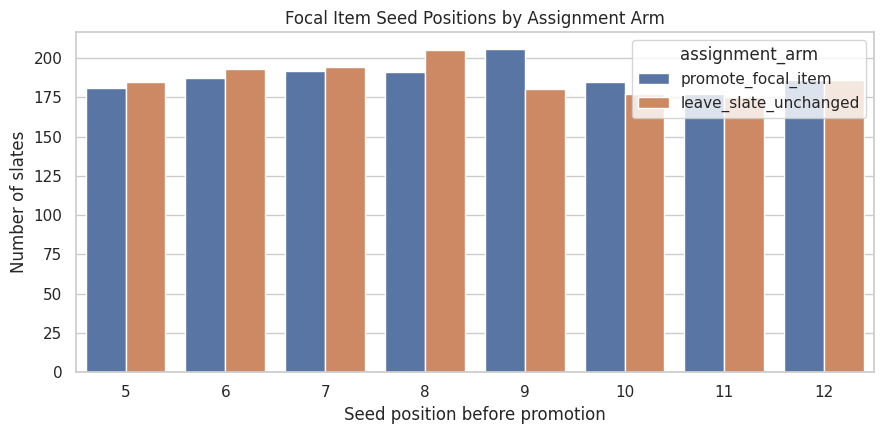

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.countplot(data=focal_items, x="focal_seed_position", hue="assignment_arm", ax=ax)
ax.set_title("Focal Item Seed Positions by Assignment Arm")
ax.set_xlabel("Seed position before promotion")
ax.set_ylabel("Number of slates")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_focal_position_assignment.png", dpi=160, bbox_inches="tight")
plt.show()


The assignment arms should have similar focal-position distributions. This matters because position gain is the mechanism of the direct effect. If one arm had much deeper focal items, promoted and control slates would not be comparable in a clean way.


### Map Direct and Spillover Exposures

This cell joins the slate-level assignment back to every item row and creates the core exposure variables.

Key variables:

- `direct_treatment`: the row is the focal item and its slate was promoted.
- `same_slate_spillover`: another item in the same slate was promoted.
- `same_cluster_spillover`: a non-focal item shares the promoted focal item's spillover cluster.
- `displaced_by_promotion`: a non-focal item was above the focal item and shifted down after promotion.
- `final_position`: the row's post-assignment position.
- `visibility_gain`: change in a simple visibility score after promotion.

This is the central mapping step of the notebook.


In [6]:
# Map direct and spillover exposures.
assignment_cols = [
    "slate_id",
    "focal_movieId",
    "focal_title",
    "focal_spillover_cluster",
    "focal_seed_position",
    "promotion_probability",
    "promotion_applied",
    "assignment_arm",
]

exposure = slate_base.merge(focal_items[assignment_cols], on="slate_id", how="left")
exposure["is_focal_item"] = (exposure["movieId"] == exposure["focal_movieId"]).astype("int8")
exposure["direct_treatment"] = (
    (exposure["is_focal_item"] == 1) & (exposure["promotion_applied"] == 1)
).astype("int8")
exposure["same_slate_spillover"] = (
    (exposure["is_focal_item"] == 0) & (exposure["promotion_applied"] == 1)
).astype("int8")
exposure["same_cluster_spillover"] = (
    (exposure["same_slate_spillover"] == 1)
    & (exposure["spillover_cluster"] == exposure["focal_spillover_cluster"])
).astype("int8")
exposure["displaced_by_promotion"] = (
    (exposure["same_slate_spillover"] == 1)
    & (exposure["slate_position_seed"] < exposure["focal_seed_position"])
).astype("int8")

exposure["final_position"] = exposure["slate_position_seed"]
promoted_mask = exposure["promotion_applied"] == 1
focal_promoted_mask = promoted_mask & (exposure["is_focal_item"] == 1)
shifted_mask = promoted_mask & (exposure["is_focal_item"] == 0) & (
    exposure["slate_position_seed"] < exposure["focal_seed_position"]
)
exposure.loc[focal_promoted_mask, "final_position"] = 1
exposure.loc[shifted_mask, "final_position"] = exposure.loc[shifted_mask, "slate_position_seed"] + 1

exposure["baseline_visibility"] = 1 / np.log2(exposure["slate_position_seed"] + 1)
exposure["final_visibility"] = 1 / np.log2(exposure["final_position"] + 1)
exposure["visibility_gain"] = exposure["final_visibility"] - exposure["baseline_visibility"]
exposure["position_change"] = exposure["final_position"] - exposure["slate_position_seed"]

exposure["exposure_group"] = np.select(
    [
        exposure["direct_treatment"] == 1,
        (exposure["is_focal_item"] == 1) & (exposure["promotion_applied"] == 0),
        exposure["same_cluster_spillover"] == 1,
        exposure["same_slate_spillover"] == 1,
    ],
    [
        "direct_promoted",
        "focal_control",
        "same_cluster_spillover",
        "other_slate_spillover",
    ],
    default="unchanged_non_focal",
)

position_validity = (
    exposure.groupby("slate_id")["final_position"]
    .agg(unique_positions="nunique", min_position="min", max_position="max")
    .reset_index()
)
invalid_position_slates = position_validity.query(
    "unique_positions != 12 or min_position != 1 or max_position != 12"
)

exposure_summary = (
    exposure.groupby("exposure_group")
    .agg(
        rows=("movieId", "size"),
        slates=("slate_id", "nunique"),
        mean_seed_position=("slate_position_seed", "mean"),
        mean_final_position=("final_position", "mean"),
        mean_visibility_gain=("visibility_gain", "mean"),
        mean_relevance=("observed_relevance", "mean"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

display(exposure_summary)
print(f"Invalid final-position slates: {len(invalid_position_slates)}")


,exposure_group,rows,slates,mean_seed_position,mean_final_position,mean_visibility_gain,mean_relevance
4,unchanged_non_focal,16445,1495,6.3230,6.3230,0.0000,4.6058
2,other_slate_spillover,12246,1500,6.3039,6.9849,-0.0622,4.6084
3,same_cluster_spillover,4309,1245,6.3613,7.0429,-0.0619,4.6239
0,direct_promoted,1505,1505,8.4930,1.0000,0.6837,4.4897
1,focal_control,1495,1495,8.4468,8.4468,0.0000,4.4893


Invalid final-position slates: 0


The exposure groups make the interference structure explicit. The promoted focal item is the direct-treatment unit. Non-focal items in promoted slates are spillover-exposed, and same-cluster non-focal items are the most important substitute group. The final-position validity check confirms that each slate still has positions 1 through 12 after the simulated promotion.


#### 7. Summarize Exposure Group Shares

This cell converts exposure counts into shares. The counts are useful, but shares make it easier to see how much data is available for each causal contrast. Same-cluster spillover rows are especially important because they represent plausible substitute displacement.


In [7]:
exposure_group_shares = exposure_summary.copy()
exposure_group_shares["row_share"] = exposure_group_shares["rows"] / exposure_group_shares["rows"].sum()
exposure_group_shares["slate_share"] = exposure_group_shares["slates"] / exposure["slate_id"].nunique()

display(exposure_group_shares)


,exposure_group,rows,slates,mean_seed_position,mean_final_position,mean_visibility_gain,mean_relevance,row_share,slate_share
4,unchanged_non_focal,16445,1495,6.3230,6.3230,0.0000,4.6058,0.4568,0.4983
2,other_slate_spillover,12246,1500,6.3039,6.9849,-0.0622,4.6084,0.3402,0.5000
3,same_cluster_spillover,4309,1245,6.3613,7.0429,-0.0619,4.6239,0.1197,0.4150
0,direct_promoted,1505,1505,8.4930,1.0000,0.6837,4.4897,0.0418,0.5017
1,focal_control,1495,1495,8.4468,8.4468,0.0000,4.4893,0.0415,0.4983


The direct-treatment group is small by design because each promoted slate has one promoted focal item. Spillover groups are larger because every other item in a promoted slate can be affected. This asymmetry is exactly why item-level analyses can be misleading if they only count the promoted item's gain.


#### 8. Plot Position Changes by Exposure Group

Promotion changes the focal item's position dramatically and shifts some other items down. This plot shows the distribution of position changes. Negative values mean a movie moved upward; positive values mean it moved downward.


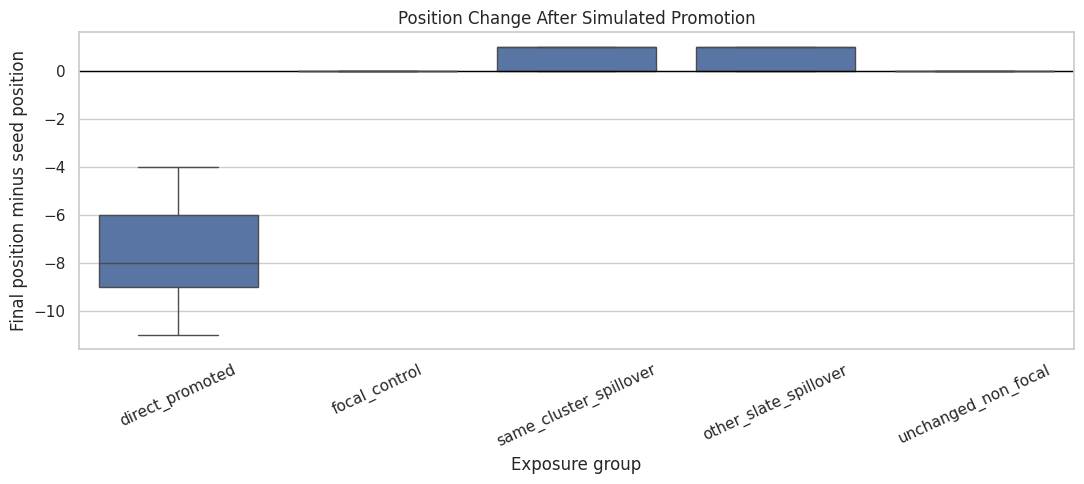

In [8]:
plot_order = [
    "direct_promoted",
    "focal_control",
    "same_cluster_spillover",
    "other_slate_spillover",
    "unchanged_non_focal",
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=exposure,
    x="exposure_group",
    y="position_change",
    order=plot_order,
    ax=ax,
    showfliers=False,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Position Change After Simulated Promotion")
ax.set_xlabel("Exposure group")
ax.set_ylabel("Final position minus seed position")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_position_change_by_exposure_group.png", dpi=160, bbox_inches="tight")
plt.show()


The plot should show a strong upward move for directly promoted focal items and downward movement for displaced non-focal items. This is the mechanical source of interference. Promotion reallocates attention within the slate.


### Same-Cluster Spillover by Genre Cluster

Same-cluster spillover is not evenly distributed across genres. This cell summarizes how often each spillover cluster appears as the promoted focal cluster and how many same-cluster competitors are exposed. This helps identify where later spillover estimates will have enough support.


In [9]:
cluster_exposure = (
    exposure.groupby("focal_spillover_cluster")
    .agg(
        randomized_slates=("slate_id", "nunique"),
        promoted_slates=("promotion_applied", "sum"),
        direct_rows=("direct_treatment", "sum"),
        same_cluster_spillover_rows=("same_cluster_spillover", "sum"),
        same_slate_spillover_rows=("same_slate_spillover", "sum"),
        mean_focal_relevance=("observed_relevance", "mean"),
    )
    .reset_index()
    .rename(columns={"focal_spillover_cluster": "promoted_focal_cluster"})
)
cluster_exposure["same_cluster_share_of_spillover"] = (
    cluster_exposure["same_cluster_spillover_rows"]
    / cluster_exposure["same_slate_spillover_rows"].replace(0, np.nan)
)
cluster_exposure = cluster_exposure.sort_values("same_cluster_spillover_rows", ascending=False)

display(cluster_exposure.head(20))


,promoted_focal_cluster,randomized_slates,promoted_slates,direct_rows,same_cluster_spillover_rows,same_slate_spillover_rows,mean_focal_relevance,same_cluster_share_of_spillover
1,Action,799,4812,401,1692,4411,4.6135,0.3836
5,Comedy,658,4056,338,1092,3718,4.5847,0.2937
8,Drama,636,3804,317,974,3487,4.5962,0.2793
2,Adventure,318,2016,168,282,1848,4.6102,0.1526
6,Crime,253,1560,130,165,1430,4.6332,0.1154
3,Animation,70,384,32,32,352,4.5744,0.0909
11,Horror,65,372,31,29,341,4.4474,0.0850
7,Documentary,42,192,16,20,176,4.6746,0.1136
4,Children,43,240,20,9,220,4.5707,0.0409
13,Mystery,44,180,15,7,165,4.5019,0.0424


Clusters with more same-cluster spillover rows will support more stable indirect-effect estimates. Sparse clusters can still be included in overall estimates, but later segment-level reporting should avoid over-interpreting very small groups.


#### 10. Plot Same-Cluster Spillover Volume

This plot focuses on the largest promoted focal clusters. It shows where substitute displacement is most observable in the simulated data.


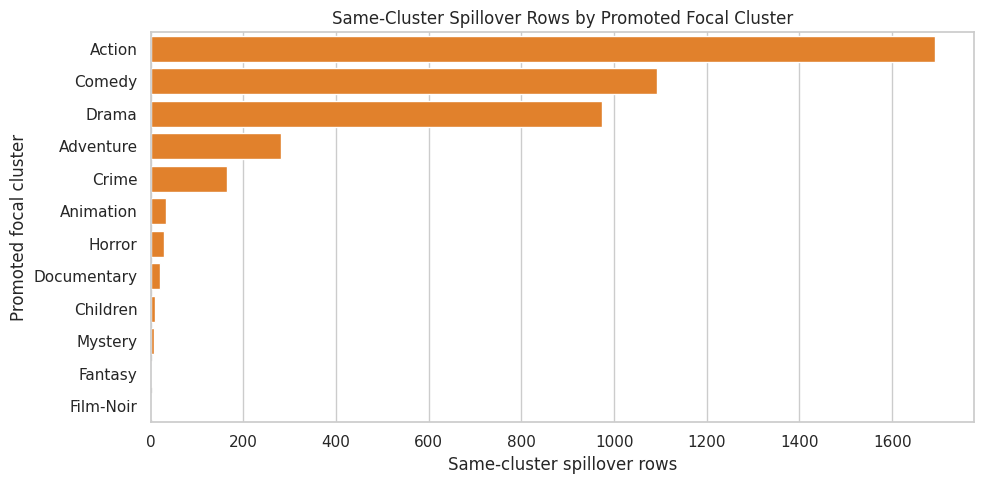

In [10]:
top_cluster_exposure = cluster_exposure.head(12).copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=top_cluster_exposure,
    x="same_cluster_spillover_rows",
    y="promoted_focal_cluster",
    ax=ax,
    color="tab:orange",
)
ax.set_title("Same-Cluster Spillover Rows by Promoted Focal Cluster")
ax.set_xlabel("Same-cluster spillover rows")
ax.set_ylabel("Promoted focal cluster")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_same_cluster_spillover_volume.png", dpi=160, bbox_inches="tight")
plt.show()


The largest clusters are the best candidates for detailed spillover analysis. This is also a product-relevant view: substitution is easier to reason about when the promoted item and competing items are in the same content family.


### Simulate Observed Outcomes Under Competition

The seed ratings tell us user-item relevance, but they are not post-promotion outcomes. This cell creates simulated binary engagement outcomes using a transparent data-generating process.

The simulated click probability depends on:

- user-item relevance from the observed rating,
- baseline user rating tendency,
- item popularity and liked rate,
- final visibility after promotion,
- a positive direct boost for promoted focal items,
- a small generic attention penalty for non-focal items in promoted slates,
- a stronger penalty for same-cluster substitutes.

The exact outcome model is synthetic, and the assumptions are explicit. That is the right setup for this interference notebook because MovieLens does not contain real randomized exposure logs.


In [11]:
# Simulate observed outcomes under competition.
def sigmoid(x):
    """
    Apply the logistic sigmoid transformation.
    
    Idea
    ----
    The simulation uses this helper to convert latent utility or score values into probabilities for generated recommendation outcomes.
    
    Parameters
    ----------
    x : object
        Project-specific input named `x` used by this helper.
    
    Returns
    -------
    numpy.ndarray
        Values transformed to the interval from zero to one.
    """
    return 1 / (1 + np.exp(-x))

outcome_rng = np.random.default_rng(RANDOM_SEED + 17)

exposure = exposure.copy()
exposure["log_item_popularity"] = np.log1p(exposure["sample_rating_count"].fillna(0))
log_pop_mean = exposure["log_item_popularity"].mean()
log_pop_std = exposure["log_item_popularity"].std()
exposure["log_item_popularity_z"] = (
    exposure["log_item_popularity"] - log_pop_mean
) / log_pop_std

base_logit = (
    -2.75
    + 0.78 * (exposure["observed_relevance"] - 3.5)
    + 1.15 * exposure["baseline_visibility"]
    + 0.35 * (exposure["liked_rate"] - exposure["liked_rate"].mean())
    + 0.25 * (exposure["sample_liked_rate"].fillna(exposure["sample_liked_rate"].mean()) - exposure["sample_liked_rate"].mean())
    + 0.10 * exposure["log_item_popularity_z"].fillna(0)
)

observed_logit = (
    -2.75
    + 0.78 * (exposure["observed_relevance"] - 3.5)
    + 1.15 * exposure["final_visibility"]
    + 0.35 * (exposure["liked_rate"] - exposure["liked_rate"].mean())
    + 0.25 * (exposure["sample_liked_rate"].fillna(exposure["sample_liked_rate"].mean()) - exposure["sample_liked_rate"].mean())
    + 0.10 * exposure["log_item_popularity_z"].fillna(0)
    + 0.20 * exposure["direct_treatment"]
    - 0.08 * exposure["same_slate_spillover"]
    - 0.24 * exposure["same_cluster_spillover"]
    - 0.10 * exposure["displaced_by_promotion"]
)

exposure["p_no_promotion"] = sigmoid(base_logit).clip(0.01, 0.95)
exposure["p_observed"] = sigmoid(observed_logit).clip(0.01, 0.95)
exposure["known_probability_lift"] = exposure["p_observed"] - exposure["p_no_promotion"]
exposure["simulated_click"] = outcome_rng.binomial(1, exposure["p_observed"]).astype("int8")
exposure["simulated_engagement_score"] = (
    exposure["simulated_click"] * (1 + 0.15 * exposure["observed_relevance"])
).astype("float32")

outcome_summary = (
    exposure.groupby("exposure_group")
    .agg(
        rows=("movieId", "size"),
        mean_probability=("p_observed", "mean"),
        mean_no_promotion_probability=("p_no_promotion", "mean"),
        mean_probability_lift=("known_probability_lift", "mean"),
        simulated_click_rate=("simulated_click", "mean"),
        mean_engagement_score=("simulated_engagement_score", "mean"),
    )
    .reset_index()
    .sort_values("mean_probability_lift", ascending=False)
)

display(outcome_summary)


,exposure_group,rows,mean_probability,mean_no_promotion_probability,mean_probability_lift,simulated_click_rate,mean_engagement_score
0,direct_promoted,1505,0.3556,0.1762,0.1794,0.3435,0.5827
1,focal_control,1495,0.1779,0.1779,0.0000,0.1719,0.2935
4,unchanged_non_focal,16445,0.2151,0.2151,0.0000,0.2141,0.3673
2,other_slate_spillover,12246,0.1784,0.2154,-0.0370,0.1770,0.3033
3,same_cluster_spillover,4309,0.1466,0.2153,-0.0686,0.1522,0.2615


The simulated outcome table should show positive probability lift for directly promoted items and negative or near-negative lift for spillover groups. This is by design: the notebook is creating a controlled environment where later estimators should recover both promoted-item gains and competitor displacement.


#### 12. Plot Simulated Outcomes by Exposure Group

This plot compares simulated click rates and known probability lift across exposure groups. It is not a causal estimate yet; it is a sanity check that the simulated data-generating process creates the expected pattern.


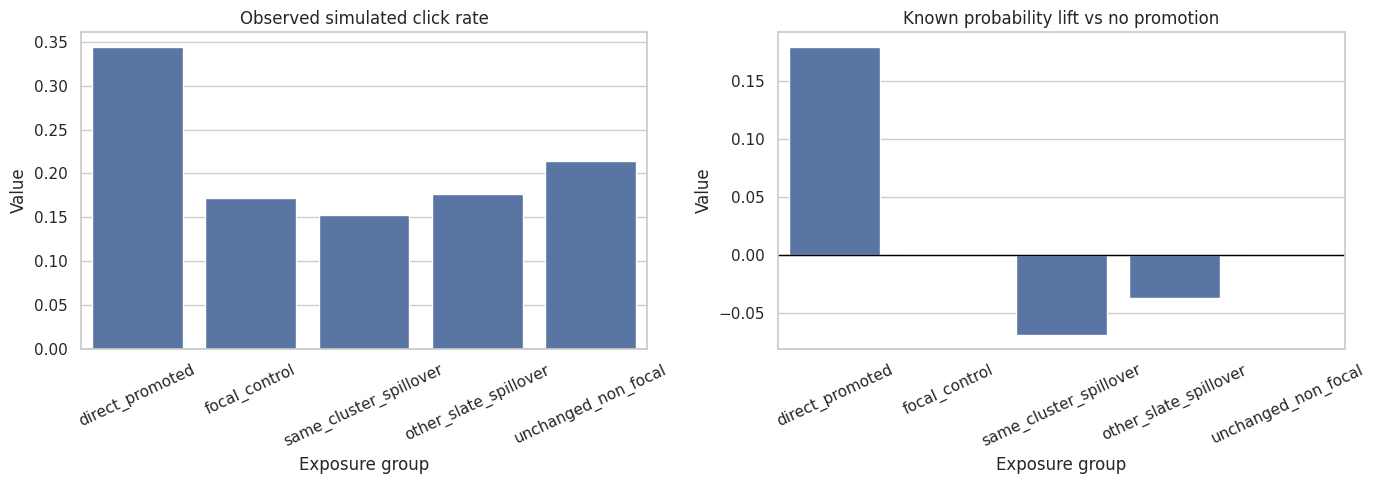

In [12]:
# Plot simulated outcomes by exposure group.
outcome_plot_df = outcome_summary.melt(
    id_vars="exposure_group",
    value_vars=["simulated_click_rate", "mean_probability_lift"],
    var_name="metric",
    value_name="value",
)
outcome_plot_df["metric"] = outcome_plot_df["metric"].map(
    {
        "simulated_click_rate": "Observed simulated click rate",
        "mean_probability_lift": "Known probability lift vs no promotion",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, outcome_plot_df["metric"].unique()):
    sns.barplot(
        data=outcome_plot_df.query("metric == @metric"),
        x="exposure_group",
        y="value",
        order=plot_order,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(metric)
    ax.set_xlabel("Exposure group")
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_simulated_outcomes_by_exposure_group.png", dpi=160, bbox_inches="tight")
plt.show()


The left panel reflects both relevance selection and exposure, while the right panel isolates the known probability change induced by the simulation. This distinction is important: raw click-rate differences are not the same as causal effects, even in a randomized simulation, because groups can differ in baseline relevance and position.


### Build Slate-Level Outcomes

Interference is often best evaluated at the slate level because one item's gain can be another item's loss. This cell aggregates item-row outcomes into slate-level totals and separates focal, same-cluster competitor, and other competitor components.


In [13]:
# Build slate-Level outcomes.
slate_outcomes = (
    exposure.groupby("slate_id")
    .agg(
        userId=("userId", "first"),
        assignment_arm=("assignment_arm", "first"),
        promotion_applied=("promotion_applied", "first"),
        focal_movieId=("focal_movieId", "first"),
        focal_title=("focal_title", "first"),
        focal_spillover_cluster=("focal_spillover_cluster", "first"),
        focal_seed_position=("focal_seed_position", "first"),
        total_simulated_clicks=("simulated_click", "sum"),
        total_expected_clicks=("p_observed", "sum"),
        total_expected_clicks_no_promotion=("p_no_promotion", "sum"),
        total_known_probability_lift=("known_probability_lift", "sum"),
        direct_expected_lift=("known_probability_lift", lambda s: s[exposure.loc[s.index, "direct_treatment"] == 1].sum()),
        same_cluster_spillover_expected_lift=("known_probability_lift", lambda s: s[exposure.loc[s.index, "same_cluster_spillover"] == 1].sum()),
        other_spillover_expected_lift=("known_probability_lift", lambda s: s[(exposure.loc[s.index, "same_slate_spillover"] == 1) & (exposure.loc[s.index, "same_cluster_spillover"] == 0)].sum()),
    )
    .reset_index()
)

slate_outcome_summary = (
    slate_outcomes.groupby("assignment_arm")
    .agg(
        slates=("slate_id", "size"),
        mean_simulated_clicks=("total_simulated_clicks", "mean"),
        mean_expected_clicks=("total_expected_clicks", "mean"),
        mean_expected_clicks_no_promotion=("total_expected_clicks_no_promotion", "mean"),
        mean_total_known_lift=("total_known_probability_lift", "mean"),
        mean_direct_expected_lift=("direct_expected_lift", "mean"),
        mean_same_cluster_spillover_expected_lift=("same_cluster_spillover_expected_lift", "mean"),
        mean_other_spillover_expected_lift=("other_spillover_expected_lift", "mean"),
    )
    .reset_index()
)

display(slate_outcome_summary)
display(slate_outcomes.head())


,assignment_arm,slates,mean_simulated_clicks,mean_expected_clicks,mean_expected_clicks_no_promotion,mean_total_known_lift,mean_direct_expected_lift,mean_same_cluster_spillover_expected_lift,mean_other_spillover_expected_lift
0,leave_slate_unchanged,1495,2.5271,2.5438,2.5438,0.0000,0.0000,0.0000,0.0000
1,promote_focal_item,1505,2.2193,2.2269,2.5450,-0.3180,0.1794,-0.1965,-0.3010


,slate_id,userId,assignment_arm,promotion_applied,focal_movieId,focal_title,focal_spillover_cluster,focal_seed_position,total_simulated_clicks,total_expected_clicks,total_expected_clicks_no_promotion,total_known_probability_lift,direct_expected_lift,same_cluster_spillover_expected_lift,other_spillover_expected_lift
0,user_100000_seed,100000,promote_focal_item,1,88810,"Help, The (2011)",Drama,8,3,1.5470,1.7488,-0.2018,0.1351,-0.0162,-0.3206
1,user_10000_seed,10000,leave_slate_unchanged,0,2005,"Goonies, The (1985)",Action,12,1,2.3210,2.3210,0.0000,0.0000,0.0000,0.0000
2,user_100050_seed,100050,promote_focal_item,1,5459,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,Action,5,3,2.4909,2.8907,-0.3998,0.1923,-0.4989,-0.0933
3,user_100100_seed,100100,leave_slate_unchanged,0,4299,"Knight's Tale, A (2001)",Action,5,5,2.9722,2.9722,0.0000,0.0000,0.0000,0.0000
4,user_100200_seed,100200,leave_slate_unchanged,0,5445,Minority Report (2002),Action,11,2,3.3004,3.3004,0.0000,0.0000,0.0000,0.0000


The slate-level table is where displacement becomes visible. A promoted focal item can have a positive direct expected lift, while same-cluster and other competitors can have negative expected lifts. The total slate lift is the net product-relevant quantity.


#### 14. Plot Slate-Level Net Lift

This plot shows the distribution of known expected total lift at the slate level. The promoted arm should have non-zero lift by construction, while the control arm should be zero because no slate positions changed.


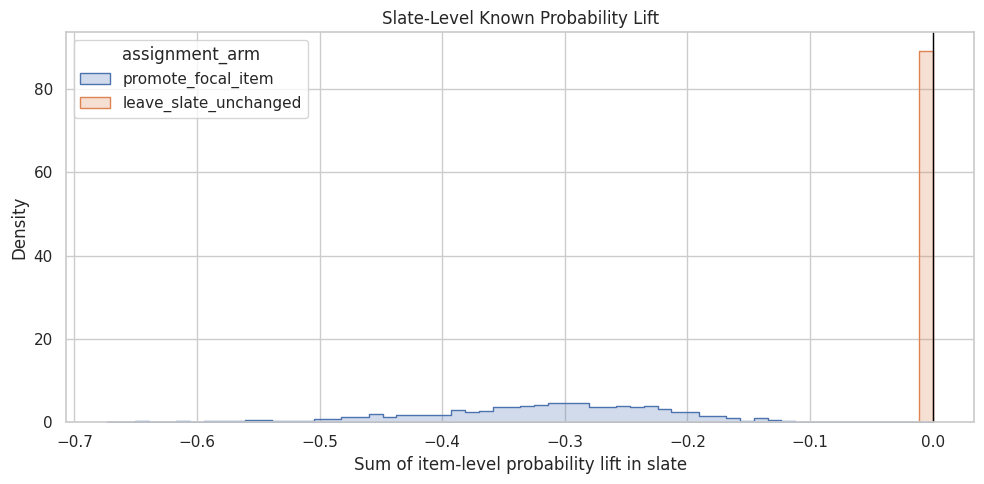

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=slate_outcomes,
    x="total_known_probability_lift",
    hue="assignment_arm",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Slate-Level Known Probability Lift")
ax.set_xlabel("Sum of item-level probability lift in slate")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "10_slate_level_known_lift.png", dpi=160, bbox_inches="tight")
plt.show()


This distribution shows why total effects matter. A promotion can be beneficial for the focal item but still have a muted or negative net slate effect if competitor displacement is large. Later notebooks will estimate this net effect from observed simulated outcomes.


### Compact Causal Design Summary

This cell summarizes the design choices and readiness checks in a compact table. The goal is to make the assumptions visible before any estimator is applied.


In [15]:
# Create a compact causal design summary.
readiness_checks = pd.DataFrame(
    [
        {
            "check": "complete_seed_slates_loaded",
            "value": exposure["slate_id"].nunique(),
            "notes": "Each slate contains 12 item rows from the setup notebook.",
        },
        {
            "check": "promotion_probability",
            "value": PROMOTION_PROBABILITY,
            "notes": "Slate-level randomized assignment probability after focal selection.",
        },
        {
            "check": "observed_promotion_rate",
            "value": exposure.drop_duplicates("slate_id")["promotion_applied"].mean(),
            "notes": "Should be close to the design probability.",
        },
        {
            "check": "direct_treatment_rows",
            "value": int(exposure["direct_treatment"].sum()),
            "notes": "One directly treated focal item per promoted slate.",
        },
        {
            "check": "same_slate_spillover_rows",
            "value": int(exposure["same_slate_spillover"].sum()),
            "notes": "Non-focal items in promoted slates.",
        },
        {
            "check": "same_cluster_spillover_rows",
            "value": int(exposure["same_cluster_spillover"].sum()),
            "notes": "Non-focal items sharing the promoted focal item's cluster.",
        },
        {
            "check": "invalid_final_position_slates",
            "value": len(invalid_position_slates),
            "notes": "Should be zero; each slate should keep positions 1 through 12.",
        },
        {
            "check": "mean_promoted_slate_known_lift",
            "value": slate_outcomes.query("promotion_applied == 1")["total_known_probability_lift"].mean(),
            "notes": "Average known net expected lift in promoted slates under the simulation.",
        },
    ]
)

display(readiness_checks)


,check,value,notes
0,complete_seed_slates_loaded,"3,000.0000",Each slate contains 12 item rows from the setu...
1,promotion_probability,0.5000,Slate-level randomized assignment probability ...
2,observed_promotion_rate,0.5017,Should be close to the design probability.
3,direct_treatment_rows,"1,505.0000",One directly treated focal item per promoted s...
4,same_slate_spillover_rows,"16,555.0000",Non-focal items in promoted slates.
5,same_cluster_spillover_rows,"4,309.0000",Non-focal items sharing the promoted focal ite...
6,invalid_final_position_slates,0.0000,Should be zero; each slate should keep positio...
7,mean_promoted_slate_known_lift,-0.3180,Average known net expected lift in promoted sl...


The readiness table is a contract for the next notebook. It says how many direct and spillover observations exist, verifies valid final positions, and records the known assignment probability. Estimation notebooks should use these diagnostics before reporting causal results.


#### 16. Save the Exposure Mapping Artifacts

This cell saves the item-row exposure mapping, slate-level outcomes, focal assignment table, and diagnostic summaries. Later notebooks can load these files directly and focus on estimation.


In [16]:
# Save the exposure mapping artifacts.
EXPOSURE_OUTPUT = PROCESSED_DIR / "movielens_interference_exposure_mapping.parquet"
SLATE_OUTCOME_OUTPUT = PROCESSED_DIR / "movielens_interference_slate_outcomes.parquet"
ASSIGNMENT_OUTPUT = PROCESSED_DIR / "movielens_interference_assignment_table.parquet"
READINESS_OUTPUT = PROCESSED_DIR / "movielens_interference_exposure_readiness.csv"
EXPOSURE_SUMMARY_OUTPUT = PROCESSED_DIR / "movielens_interference_exposure_group_summary.csv"
CLUSTER_EXPOSURE_OUTPUT = PROCESSED_DIR / "movielens_interference_cluster_exposure_summary.csv"

exposure.to_parquet(EXPOSURE_OUTPUT, index=False)
slate_outcomes.to_parquet(SLATE_OUTCOME_OUTPUT, index=False)
focal_items.to_parquet(ASSIGNMENT_OUTPUT, index=False)
readiness_checks.to_csv(READINESS_OUTPUT, index=False)
exposure_group_shares.to_csv(EXPOSURE_SUMMARY_OUTPUT, index=False)
cluster_exposure.to_csv(CLUSTER_EXPOSURE_OUTPUT, index=False)

saved_artifacts = pd.DataFrame(
    {
        "artifact": [
            "item_row_exposure_mapping",
            "slate_level_outcomes",
            "focal_assignment_table",
            "readiness_checks",
            "exposure_group_summary",
            "cluster_exposure_summary",
        ],
        "path": [
            str(EXPOSURE_OUTPUT),
            str(SLATE_OUTCOME_OUTPUT),
            str(ASSIGNMENT_OUTPUT),
            str(READINESS_OUTPUT),
            str(EXPOSURE_SUMMARY_OUTPUT),
            str(CLUSTER_EXPOSURE_OUTPUT),
        ],
    }
)

display(saved_artifacts)


,artifact,path
0,item_row_exposure_mapping,/home/apex/Documents/portfolio/data/processed/...
1,slate_level_outcomes,/home/apex/Documents/portfolio/data/processed/...
2,focal_assignment_table,/home/apex/Documents/portfolio/data/processed/...
3,readiness_checks,/home/apex/Documents/portfolio/data/processed/...
4,exposure_group_summary,/home/apex/Documents/portfolio/data/processed/...
5,cluster_exposure_summary,/home/apex/Documents/portfolio/data/processed/...


The saved exposure mapping is the main output of this notebook. It contains treatment, spillover, position, visibility, simulated outcome, and assignment variables at the item-row level. That table is ready for direct-effect and spillover-effect estimators.


### Takeaways and Next Step

This notebook converted MovieLens seed slates into a randomized interference simulation:

- One eligible lower-ranked focal item was selected in each slate.
- Slates were randomized to promote the focal item or leave the slate unchanged.
- Direct treatment, same-slate spillover, same-cluster spillover, displacement, and final position were explicitly mapped.
- Simulated outcomes were generated from relevance, visibility, and competition assumptions.
- Item-level and slate-level outputs were saved for the next estimation notebook.

The next notebook should estimate direct, spillover, and total effects using the randomized assignment. A natural next step is `03_cluster_randomized_estimators.ipynb`, which can compare simple difference-in-means estimators, cluster-robust standard errors, and slate-level total-effect estimates.
